In [1]:
# pip install requests

import requests
from IPython.display import Image
from requests.exceptions import HTTPError


In [19]:
resp = requests.get("https://theguardian.com/")
req  = resp.request

In [3]:
print(dir(resp))

['__attrs__', '__bool__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__nonzero__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_content', '_content_consumed', '_next', 'apparent_encoding', 'close', 'connection', 'content', 'cookies', 'elapsed', 'encoding', 'headers', 'history', 'is_permanent_redirect', 'is_redirect', 'iter_content', 'iter_lines', 'json', 'links', 'next', 'ok', 'raise_for_status', 'raw', 'reason', 'request', 'status_code', 'text', 'url']


In [4]:
print(dir(req))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_body_position', '_cookies', '_encode_files', '_encode_params', '_get_idna_encoded_host', 'body', 'copy', 'deregister_hook', 'headers', 'hooks', 'method', 'path_url', 'prepare', 'prepare_auth', 'prepare_body', 'prepare_content_length', 'prepare_cookies', 'prepare_headers', 'prepare_hooks', 'prepare_method', 'prepare_url', 'register_hook', 'url']


In [10]:
print(resp.status_code)

200


Di Default Requests seguirà i flussi automatici di redirect per tutti i metodi HTTP tranne che per HEAD

Per esaminare i redirect esaminiamo la proprietà `history` della risposta


In [16]:
# Inspect history
print(resp.history)
r_301 = resp.history[0]
r_302 = resp.history[1]
print(r_301.headers['Location'])
print(r_302.headers['Location'])
print(resp.url)

[<Response [301]>, <Response [302]>]
https://www.theguardian.com/
/international
https://www.theguardian.com/international


Se stiamo usando i metodi GET, OPTIONS, POST, PUT, PATCH o DELETE, possiamo disabilitare il redirect col parametro `allow_redirects`

In [17]:
r = requests.get('https://theguardian.com', allow_redirects=False)

print(r.status_code)
head_r = requests.head('https://theguardian.com')

print(head_r.status_code)

301
301


In [18]:
print(r.status_code)
print(r.content)
print(head_r.status_code)
print(head_r.content)

301
b''
301
b''


In [20]:
print(type(resp.content))
print(type(resp.text))
print(type(resp.raw))

print(resp.raw.version)

<class 'bytes'>
<class 'str'>
<class 'urllib3.response.HTTPResponse'>
11


In [21]:

for url in ['https://www.theguardian.com', 'https://repubblica.it/doesNotExist']:
    try:
        response = requests.get(url)

        # If the response was successful, no Exception will be raised
        response.raise_for_status()
    except HTTPError as http_err:
        print(type(http_err))
        print(dir(http_err))
        print(f'HTTP error: {http_err}')  
    except Exception as err:
        print(f'Generic error: {err}')  
    else:
        print('Success!')

Success!
<class 'requests.exceptions.HTTPError'>
['__cause__', '__class__', '__context__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__suppress_context__', '__traceback__', '__weakref__', 'args', 'characters_written', 'errno', 'filename', 'filename2', 'request', 'response', 'strerror', 'with_traceback']
HTTP error: 404 Client Error: Not Found for url: https://www.repubblica.it/doesNotExist


In [22]:
payload = {'key1': 'value1', 'key2': 'value2'}
r = requests.get('https://httpbin.org/get', params=payload)

#https://httpbin.org/get?key1=value1&key2=value2

print(r.text)

{
  "args": {
    "key1": "value1", 
    "key2": "value2"
  }, 
  "headers": {
    "Accept": "*/*", 
    "Accept-Encoding": "gzip, deflate", 
    "Host": "httpbin.org", 
    "User-Agent": "python-requests/2.27.1", 
    "X-Amzn-Trace-Id": "Root=1-621d133e-41fe181c4a419991508861ba"
  }, 
  "origin": "93.48.55.92", 
  "url": "https://httpbin.org/get?key1=value1&key2=value2"
}



`requests` offre un'interfaccia molto comoda anche per risposte diverse dai classici file html:

In [23]:
image = requests.get(
    "https://images.pexels.com/photos/9004904/pexels-photo-9004904.jpeg?auto=compress&cs=tinysrgb&dpr=2&h=750&w=1260"
)

with open("files/image.jpeg", "wb") as f:
    f.write(image.content)


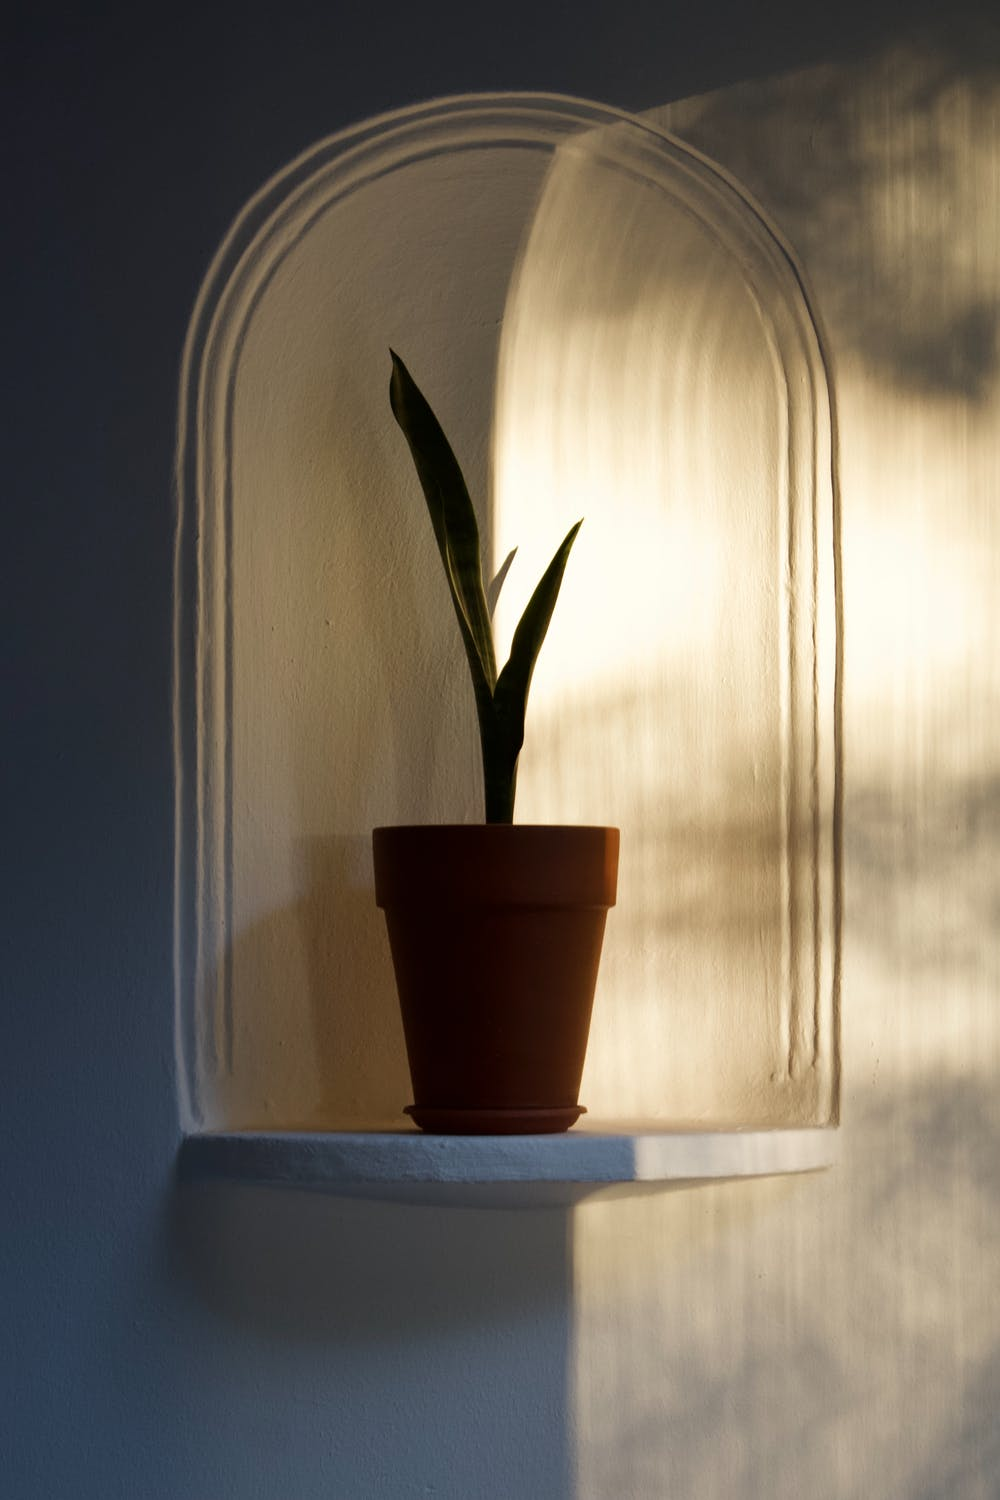

In [24]:
from IPython.display import Image
Image(filename='files/image.jpeg') 

In [29]:
json_resp = requests.get('https://jsonplaceholder.typicode.com/todos/')

print(type(json_resp.json()))

l = json_resp.json()

print(l[0].keys())

for i in range(0, 2):
    item = l[i]
    print(f"User -> {item['userId']}")
    print(f"Title -> {item['title']}")
    print(f"completed -> {item['completed']}")
    print("\n")
    
task_string = requests.get('https://jsonplaceholder.typicode.com/todos/2')
print(task_string.json()['title'])


<class 'list'>
dict_keys(['userId', 'id', 'title', 'completed'])
User -> 1
Title -> delectus aut autem
completed -> False


User -> 1
Title -> quis ut nam facilis et officia qui
completed -> False


quis ut nam facilis et officia qui


È possibile inserire nella richiesta HTTP degli header custom:


In [31]:
response = requests.get("https://www.lefigaro.fr/")

print(response.request.headers)
print(response.headers['Content-Encoding'])


custom_headers = {
    'Accept-Language': 'fr-CH, fr;q=0.9, en;q=0.8, de;q=0.7, *;q=0.5',
    'Accept-Encoding': 'compress, deflate' 
}

response = requests.get("https://www.lefigaro.fr/", headers=custom_headers)

print(response.request.headers)


{'User-Agent': 'python-requests/2.27.1', 'Accept-Encoding': 'gzip, deflate', 'Accept': '*/*', 'Connection': 'keep-alive'}
gzip
{'User-Agent': 'python-requests/2.27.1', 'Accept-Encoding': 'compress, deflate', 'Accept': '*/*', 'Connection': 'keep-alive', 'Accept-Language': 'fr-CH, fr;q=0.9, en;q=0.8, de;q=0.7, *;q=0.5'}


In [33]:
import json
payload = {
    'key1': 'value1', 
    'key2': 'value2'
}
r = requests.post("http://httpbin.org/post", data=json.dumps(payload))

In [34]:
print(r.text)

{
  "args": {}, 
  "data": "{\"key1\": \"value1\", \"key2\": \"value2\"}", 
  "files": {}, 
  "form": {}, 
  "headers": {
    "Accept": "*/*", 
    "Accept-Encoding": "gzip, deflate", 
    "Content-Length": "36", 
    "Host": "httpbin.org", 
    "User-Agent": "python-requests/2.27.1", 
    "X-Amzn-Trace-Id": "Root=1-621d1511-68e88c5e67268af06fc5e2d7"
  }, 
  "json": {
    "key1": "value1", 
    "key2": "value2"
  }, 
  "origin": "93.48.55.92", 
  "url": "http://httpbin.org/post"
}



In [35]:
r = requests.post("http://httpbin.org/post", data=payload)

In [36]:
print(r.text)

{
  "args": {}, 
  "data": "", 
  "files": {}, 
  "form": {
    "key1": "value1", 
    "key2": "value2"
  }, 
  "headers": {
    "Accept": "*/*", 
    "Accept-Encoding": "gzip, deflate", 
    "Content-Length": "23", 
    "Content-Type": "application/x-www-form-urlencoded", 
    "Host": "httpbin.org", 
    "User-Agent": "python-requests/2.27.1", 
    "X-Amzn-Trace-Id": "Root=1-621d1526-086b3e577d77523b3d8b27dc"
  }, 
  "json": null, 
  "origin": "93.48.55.92", 
  "url": "http://httpbin.org/post"
}

